<a href="https://colab.research.google.com/github/panaddatappoomee/food-selection-data-science/blob/main/project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ขั้นที่ 1 — เตรียมข้อมูล
ข้อมูลหนังสือ : กำหนดรหัสหนังสือ(D000-001ถึงD900-015), หมวดหมู่(D000-D900), ชื่อผู้แต่ง, ชื่อหนังสือ

ข้อมูลสมาชิก : กำหนดรหัสสมาชิก(PS0001-PT0050), หมวดหมู่สมาชิก(นักศึกษา,อาจารย์)

ข้อมูลหลักที่ต้องเก็บ: หนังสือ, สมาชิก, การยืมคืน
คุณสมบัติ
หนังสือ: รหัสหนังสือ, ชื่อเรื่อง, ชื่อผู้แต่ง, หมวดหมู่, สถานะ(ว่าง/ถูกยืม)

สมาชิก: รหัสสมาชิก, ชื่อ, ประเภทสมาชิก(นักศึกษา/อาจารย์), จำนวนวันที่ยืมได้

การยืม: รหัสการยืม, หนังสือที่ยืม, สมาชิกที่ยืม, วันที่ยืม, กำหนดคืน, วันที่คืนจริง

หน้าที่
หนังสือ: ยืม, คืน

การยืม: คำนวณค่าปรับ, บันทึกการคืน

การตัดสินใจหรือคำนวณที่ซับซ้อน
ระยะเวลาการยืมต่างกัน นักศึกษายืมได้ 14 วัน อาจารย์ยืมได้ 30 วัน

ค่าปรับตามจำนวนวันที่คืนช้า 5บาทต่อวัน

In [467]:
!pip install openpyxl
import pandas as pd

In [468]:
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

# 1. ติดตั้งฟอนต์ภาษาไทยลงในระบบ Colab
!apt-get -y install fonts-thai-tlwg > /dev/null 2>&1

# 2. โหลดไฟล์ฟอนต์เข้า Memory และตั้งค่า font_prop
font_path = "/usr/share/fonts/truetype/tlwg/Laksaman.ttf"
font_prop = fm.FontProperties(fname=font_path)

# 3. ตั้งค่า Default ให้ Matplotlib รู้จักฟอนต์และรองรับเครื่องหมายลบ
fm.fontManager.addfont(font_path)
plt.rcParams['font.family'] = font_prop.get_name()
plt.rcParams['axes.unicode_minus'] = False

# ขั้นที่ 2 — ออกแบบ Class

In [494]:
import random
from datetime import datetime, timedelta

In [495]:
class Book:
    def __init__(self, book_id, title, author, category_code, category_name, status="ว่าง"):
        self.book_id = book_id
        self.title = title
        self.author = author
        self.category_code = category_code
        self.category_name = category_name
        self.is_available = (status == "ว่าง")

    def borrow(self):
        """เปลี่ยนสถานะเป็นถูกยืม"""
        self.is_available = False

    def return_book(self):
        """เปลี่ยนสถานะกลับเป็นว่าง"""
        self.is_available = True


class Member:
    def __init__(self, member_id, name, member_type, loan_period_days):
        self.member_id = member_id
        self.name = name
        self.member_type = member_type
        self.loan_period_days = loan_period_days


class BookLoan:
    FINE_PER_DAY = 5

    def __init__(self, loan_id, book, member, borrow_date):
        self.loan_id = loan_id
        self.book = book
        self.member = member
        self.borrow_date = borrow_date

        # กำหนดวันส่งคืนตามสิทธิ์สมาชิก
        self.due_date = borrow_date + timedelta(days=member.loan_period_days)
        self.return_date = None

        # บันทึกว่าหนังสือถูกยืมทันทีเมื่อสร้างรายการ
        self.book.borrow()

    def calculate_late_fee(self):
        """คำนวณค่าปรับถ้าคืนช้ากว่ากำหนด"""
        if self.return_date is not None and self.return_date > self.due_date:
            late_days = (self.return_date - self.due_date).days
            return late_days * self.FINE_PER_DAY

        return 0

    def mark_returned(self, return_date):
        """บันทึกว่าคืนหนังสือแล้ว"""

        self.return_date = return_date
        self.book.return_book()

# ขั้นที่ 3 — เขียนฟังก์ชันช่วยงาน (Helper Functions)

In [496]:
import pandas as pd


def load_books(csv_path):
    """โหลดหนังสือจากไฟล์ CSV แล้วสร้างเป็น Book object"""

    df = pd.read_csv("/content/books.csv")

    return [
        Book(
            row.book_id,
            row.title,
            row.author,
            row.category_code,
            row.category_name,
            row.status
        )
        for row in df.itertuples(index=False)
    ]


def load_members(csv_path):
    """โหลดสมาชิกจากไฟล์ CSV แล้วสร้างเป็น Member object"""

    df = pd.read_csv("/content/members.csv")

    return [
        Member(
            row.member_id,
            row.name,
            row.member_type,
            row.loan_period_days
        )
        for row in df.itertuples(index=False)
    ]


def random_borrow_date(start_date, days_range=300):
    """ฟังก์ชัน: สุ่มวันที่เริ่มยืมหนังสือจากวันที่กำหนด -> คืนค่าเป็น datetime"""

    offset = random.randint(0, days_range)

    return start_date + timedelta(days=offset)


def decide_return_outcome(
    never_return_probability=0.20,
    late_probability=0.25
):
    """ฟังก์ชัน: สุ่มสถานะผลลัพธ์การคืนหนังสือตามความน่าจะเป็น -> คืนค่าเป็น string"""

    r = random.random()

    if r < never_return_probability:
        return "not_returned"

    elif r < never_return_probability + late_probability:
        return "late"

    else:
        return "on_time"


def calculate_return_date(due_date, outcome):
    """ฟังก์ชัน: คำนวณวันที่นำหนังสือมาคืนจริงตามสถานะผลลัพธ์ -> คืนค่าเป็น datetime หรือ None"""

    if outcome == "not_returned":
        return None

    elif outcome == "late":
        return due_date + timedelta(days=random.randint(1, 10))

    else:
        return due_date - timedelta(days=random.randint(0, 5))

# ทดสอบฟังก์ชันทีละตัว ก่อนเอาไปประกอบเป็นกระบวนการ

In [502]:
print("ทดสอบที่ 1: load_books และ load_members จากไฟล์จริง")
try:
    books = load_books("/content/books.csv")
    members = load_members("/content/members.csv")

    print(f"✅ โหลดหนังสือสำเร็จทั้งหมด: {len(books)} เล่ม")
    print(
        f"   ตัวอย่างเล่มแรก: {books[0].title} (สถานะพร้อมยืม: {books[0].is_available})"
    )

    print(f"✅ โหลดสมาชิกสำเร็จทั้งหมด: {len(members)} คน")
    print(
        f"   ตัวอย่างคนแรก: {members[0].name} (ยืมได้ {members[0].loan_period_days} วัน)"
    )
except FileNotFoundError as e:
    print(
        f"❌ ไม่พบไฟล์ CSV! กรุณาเช็กชื่อและพาธไฟล์อีกครั้ง: {e.filename}"
    )
except Exception as e:
    print(f"❌ เกิดข้อผิดพลาดในการอ่านไฟล์: {e}")

print("-" * 50)

ทดสอบที่ 1: load_books และ load_members จากไฟล์จริง
✅ โหลดหนังสือสำเร็จทั้งหมด: 150 เล่ม
   ตัวอย่างเล่มแรก: พื้นฐานการเขียนโปรแกรมด้วย Python (สถานะพร้อมยืม: True)
✅ โหลดสมาชิกสำเร็จทั้งหมด: 350 คน
   ตัวอย่างคนแรก: รติ (ยืมได้ 14 วัน)
--------------------------------------------------


In [504]:
print("ทดสอบที่ 2: random_borrow_date")
start_date = datetime(2026, 1, 1)
sample_borrow_date = random_borrow_date(start_date, days_range=30)
print(f"วันเริ่มสุ่ม: {start_date.strftime('%Y-%m-%d')}")
print(f"วันที่สุ่มได้: {sample_borrow_date.strftime('%Y-%m-%d')}")
print("-" * 50)

ทดสอบที่ 2: random_borrow_date
วันเริ่มสุ่ม: 2026-01-01
วันที่สุ่มได้: 2026-01-20
--------------------------------------------------


In [505]:
print("ทดสอบที่ 3: decide_return_outcome")
results = [decide_return_outcome() for _ in range(5)]
print(f"ผลการสุ่มคืนหนังสือ 5 ครั้ง: {results}")
print("-" * 50)

ทดสอบที่ 3: decide_return_outcome
ผลการสุ่มคืนหนังสือ 5 ครั้ง: ['on_time', 'on_time', 'late', 'on_time', 'late']
--------------------------------------------------


In [506]:
print("ทดสอบที่ 4: calculate_return_date")
due_date = datetime(2026, 8, 10)

return_on_time = calculate_return_date(due_date, "on_time")
return_late = calculate_return_date(due_date, "late")
return_never = calculate_return_date(due_date, "not_returned")

print(f"กำหนดคืน: {due_date.strftime('%Y-%m-%d')}")
print(
    f"กรณี คืนตรงเวลา (on_time): {return_on_time.strftime('%Y-%m-%d') if return_on_time else 'ไม่คืน'}"
)
print(
    f"กรณี คืนสาย (late): {return_late.strftime('%Y-%m-%d') if return_late else 'ไม่คืน'}"
)
print(f"กรณี ไม่คืนเลย (not_returned): {return_never}")
print("-" * 50)

ทดสอบที่ 4: calculate_return_date
กำหนดคืน: 2026-08-10
กรณี คืนตรงเวลา (on_time): 2026-08-05
กรณี คืนสาย (late): 2026-08-12
กรณี ไม่คืนเลย (not_returned): None
--------------------------------------------------


In [482]:
import random
from datetime import datetime, timedelta


def format_currency(amount, symbol="บาท"):
    """จัดรูปแบบตัวเลขเป็นสตริงเงิน เช่น 15.00 บาท"""
    return f"{amount:,.2f} {symbol}"


def simulate_member_visit(loan_id, member, book):
    """รับข้อมูลรหัสรายการ, สมาชิก, และหนังสือ -> จำลองกระบวนการยืมและคืน"""
    # กำหนดวันที่ยืม
    borrow_date = datetime(2025, 1, 1) + timedelta(days=random.randint(0, 30))

    # สร้างรายการยืม
    loan = BookLoan(loan_id, book, member, borrow_date)

    # ประมวลผลการคืนหนังสือ
    outcome = decide_return_outcome()
    return_date = calculate_return_date(loan.due_date, outcome)

    if return_date is not None:
        loan.mark_returned(return_date)

    # แสดงผลลัพธ์แบบเล่าเรื่อง
    print("=" * 60)
    print(
        f"📖 ออเดอร์ #{loan.loan_id}: คุณ '{member.name}' (รหัสสมาชิก:"
        f" {member.member_id}) เข้ามายืมหนังสือ"
    )
    print(
        f"📚 หนังสือที่เลือก: '{book.title}' (รหัสหนังสือ: {book.book_id}) โดย"
        f" {book.author}"
    )
    print(f"🗓️ วันที่ยืม: {borrow_date.strftime('%Y-%m-%d')}")
    print(f"⏰ กำหนดคืน: {loan.due_date.strftime('%Y-%m-%d')}")

    if loan.return_date:
        late_fee = loan.calculate_late_fee()
        print(
            f"✅ คืนหนังสือแล้วในวันที่ {loan.return_date.strftime('%Y-%m-%d')}"
        )
        if late_fee > 0:
            print(
                f"⚠️ เกินกำหนดส่งคืน! ค่าปรับสุทธิ: {format_currency(late_fee)}"
            )
        else:
            print("🎉 คืนตรงเวลา ไม่มีค่าปรับ")
    else:
        print("⚠️ ยังไม่คืนหนังสือ")
    print("=" * 60)

    return loan

In [483]:
# --- เรียกใช้งานจริงกับสมาชิก 1 คน ---

# 1. โหลดข้อมูลจาก CSV
members = load_members("members.csv")
books = load_books("books.csv")

# 2. เลือกสมาชิกคนแรก และสุ่มหนังสือ 1 เล่มจาก CSV
member_a = members[0]
book_a = random.choice(books)

# 3. เรียกใช้งานฟังก์ชันจำลองสำหรับสมาชิกคนแรก (ออเดอร์ #1)
order_a = simulate_member_visit(loan_id="L001", member=member_a, book=book_a)

📖 ออเดอร์ #L001: คุณ 'รติ' (รหัสสมาชิก: PS0001) เข้ามายืมหนังสือ
📚 หนังสือที่เลือก: 'พิธีกรรมและประเพณีทางศาสนา' (รหัสหนังสือ: D200-009) โดย จรัส วัฒนธรรม
🗓️ วันที่ยืม: 2025-01-20
⏰ กำหนดคืน: 2025-02-03
✅ คืนหนังสือแล้วในวันที่ 2025-02-01
🎉 คืนตรงเวลา ไม่มีค่าปรับ


In [484]:
members = load_members("members.csv")
books = load_books("books.csv")

# สุ่มเลือกสมาชิกที่จะเดินเข้ามาในวันนี้จำนวน 5 คน
walk_in_members = random.sample(members, k=min(5, len(members)))

completed_orders = []  # เก็บผลลัพธ์ของทุกออเดอร์ที่จำลองในรอบนี้

# เรียก simulate_member_visit() ซ้ำหลายๆ ครั้งผ่าน loop
for i, mem in enumerate(walk_in_members, start=1):
    loan_code = f"L{i:03d}"  # สร้างรหัสเช่น L001, L002, L003...
    selected_book = random.choice(books)  # สุ่มหนังสือที่สมาชิกเลือก

    # เรียกใช้ฟังก์ชันจำลอง
    order = simulate_member_visit(
        loan_id=loan_code, member=mem, book=selected_book
    )
    completed_orders.append(order)

print("=" * 60)
print(
    f"🏁 จบรอบสาธิต — วันนี้มีสมาชิกเข้ามาใช้บริการห้องสมุดทั้งหมด"
    f" {len(completed_orders)} คน"
)

📖 ออเดอร์ #L001: คุณ 'โอโซน' (รหัสสมาชิก: PS0034) เข้ามายืมหนังสือ
📚 หนังสือที่เลือก: 'การเขียนบทความสร้างสรรค์' (รหัสหนังสือ: D800-014) โดย นักเขียนอิสระ ความคิดใหม่
🗓️ วันที่ยืม: 2025-01-26
⏰ กำหนดคืน: 2025-02-09
⚠️ ยังไม่คืนหนังสือ
📖 ออเดอร์ #L002: คุณ 'ภา' (รหัสสมาชิก: PT0011) เข้ามายืมหนังสือ
📚 หนังสือที่เลือก: 'อาณาจักรโบราณในดินแดนไทย' (รหัสหนังสือ: D900-014) โดย นักประวัติศาสตร์ สุโขทัยอยุธยา
🗓️ วันที่ยืม: 2025-01-04
⏰ กำหนดคืน: 2025-02-03
⚠️ ยังไม่คืนหนังสือ
📖 ออเดอร์ #L003: คุณ 'ชะเอม' (รหัสสมาชิก: PS0185) เข้ามายืมหนังสือ
📚 หนังสือที่เลือก: 'ประวัติศาสตร์ไทยเบื้องต้น' (รหัสหนังสือ: D900-001) โดย นักประวัติศาสตร์ อดีตกาล
🗓️ วันที่ยืม: 2025-01-01
⏰ กำหนดคืน: 2025-01-15
⚠️ ยังไม่คืนหนังสือ
📖 ออเดอร์ #L004: คุณ 'มัชฌิ์' (รหัสสมาชิก: PS0213) เข้ามายืมหนังสือ
📚 หนังสือที่เลือก: 'เคมีอินทรีย์เบื้องต้น' (รหัสหนังสือ: D500-011) โดย คาร์บอน โมเลกุล
🗓️ วันที่ยืม: 2025-01-11
⏰ กำหนดคืน: 2025-01-25
✅ คืนหนังสือแล้วในวันที่ 2025-01-21
🎉 คืนตรงเวลา ไม่มีค่าปรับ
📖 ออเดอร์ #L005: คุณ 'นุ่น' 

In [485]:
# รวมออเดอร์แรก (L001) เข้ากับออเดอร์ที่เหลือจากในลูป (L002, L003, L004)
all_demo_orders = [order_a] + completed_orders

print("=" * 60)
print(f"📊 สรุปภาพรวมการจำลองทั้งหมด:")
print(f"   จำนวนออเดอร์ทั้งหมด: {len(all_demo_orders)} รายการ")
for order in all_demo_orders:
    fee = order.calculate_late_fee()
    fee_str = format_currency(fee) if fee > 0 else "ไม่มีค่าปรับ"
    print(f"   • รหัส: {order.loan_id} | สมาชิก: {order.member.name} | หนังสือ: {order.book.title} | ค่าปรับ: {fee_str}")
print("=" * 60)

📊 สรุปภาพรวมการจำลองทั้งหมด:
   จำนวนออเดอร์ทั้งหมด: 6 รายการ
   • รหัส: L001 | สมาชิก: รติ | หนังสือ: พิธีกรรมและประเพณีทางศาสนา | ค่าปรับ: ไม่มีค่าปรับ
   • รหัส: L001 | สมาชิก: โอโซน | หนังสือ: การเขียนบทความสร้างสรรค์ | ค่าปรับ: ไม่มีค่าปรับ
   • รหัส: L002 | สมาชิก: ภา | หนังสือ: อาณาจักรโบราณในดินแดนไทย | ค่าปรับ: ไม่มีค่าปรับ
   • รหัส: L003 | สมาชิก: ชะเอม | หนังสือ: ประวัติศาสตร์ไทยเบื้องต้น | ค่าปรับ: ไม่มีค่าปรับ
   • รหัส: L004 | สมาชิก: มัชฌิ์ | หนังสือ: เคมีอินทรีย์เบื้องต้น | ค่าปรับ: ไม่มีค่าปรับ
   • รหัส: L005 | สมาชิก: นุ่น | หนังสือ: การพัฒนาเว็บไซต์สมัยใหม่ | ค่าปรับ: 10.00 บาท


In [516]:
import pandas as pd

summary_rows = [
    {
        "loan_id": o.loan_id,
        "member_id": o.member.member_id,
        "member_name": o.member.name,
        "book_title": o.book.title,
        "borrow_date": o.borrow_date.strftime("%Y-%m-%d"),
        "due_date": o.due_date.strftime("%Y-%m-%d"),
        "return_date": (
            o.return_date.strftime("%Y-%m-%d") if o.return_date else "ยังไม่คืน"
        ),
        "late_fee": o.calculate_late_fee(),
        "status": "คืนแล้ว" if o.return_date else "ค้างส่ง",
    }
    for o in all_demo_orders
]

demo_summary_df = pd.DataFrame(summary_rows)
demo_summary_df

,loan_id,member_id,member_name,book_title,borrow_date,due_date,return_date,late_fee,status
0,L001,PS0001,รติ,พิธีกรรมและประเพณีทางศาสนา,2025-01-20,2025-02-03,2025-02-01,0,คืนแล้ว
1,L001,PS0034,โอโซน,การเขียนบทความสร้างสรรค์,2025-01-26,2025-02-09,ยังไม่คืน,0,ค้างส่ง
2,L002,PT0011,ภา,อาณาจักรโบราณในดินแดนไทย,2025-01-04,2025-02-03,ยังไม่คืน,0,ค้างส่ง
3,L003,PS0185,ชะเอม,ประวัติศาสตร์ไทยเบื้องต้น,2025-01-01,2025-01-15,ยังไม่คืน,0,ค้างส่ง
4,L004,PS0213,มัชฌิ์,เคมีอินทรีย์เบื้องต้น,2025-01-11,2025-01-25,2025-01-21,0,คืนแล้ว
5,L005,PS0201,นุ่น,การพัฒนาเว็บไซต์สมัยใหม่,2025-01-21,2025-02-04,2025-02-06,10,คืนแล้ว


# ขั้นที่ 4 — จำลองข้อมูลทีละรายการด้วย Loop

In [560]:
import random
from datetime import datetime, timedelta
import pandas as pd


# 1. ฟังก์ชันจำลองการยืมแบบไม่พิมพ์ข้อความ (สำหรับ Batch Large-scale)
def simulate_borrow_batch(
    num_records=350,
    start_date=datetime(2026, 1, 1),
    days_range=180,
    seed=None,  # <-- เพิ่ม seed=None ตรงนี้ครับ
):
    """จำลองการยืมหนังสือจำนวนหลายรายการแบบรวดเร็ว (ไม่มีการ print) -> คืนค่าเป็น DataFrame"""
    if seed is not None:
        random.seed(seed)  # ตั้งค่า seed ก่อนเริ่มการสุ่มทั้งหมด

    members = load_members("members.csv")
    books = load_books("books.csv")

    records = []

    for i in range(1, num_records + 1):
        loan_id = f"L{i:04d}"

        # สุ่มสมาชิก หนังสือ และวันที่ยืม
        member = random.choice(members)
        book = random.choice(books)
        borrow_date = start_date + timedelta(
            days=random.randint(0, days_range)
        )

        # สร้าง Object และคำนวณการคืน
        loan = BookLoan(loan_id, book, member, borrow_date)
        outcome = decide_return_outcome()
        return_date = calculate_return_date(loan.due_date, outcome)

        if return_date is not None:
            loan.mark_returned(return_date)

       # เก็บข้อมูลลงใน dict เพื่อแปลงเป็น DataFrame
        records.append({
            "loan_id": loan.loan_id,
            "member_id": loan.member.member_id,
            "member_name": loan.member.name,
            "member_type": loan.member.member_type,
            "book_id": loan.book.book_id,
            "book_title": loan.book.title,
            "borrow_date": loan.borrow_date.strftime("%Y-%m-%d"),
            "due_date": loan.due_date.strftime("%Y-%m-%d"),
            "return_date": (
                loan.return_date.strftime("%Y-%m-%d")
                if loan.re  #turn_date
                else None
            ),
            "late_fee": loan.calculate_late_fee(),
            "status": "คืนแล้ว" if loan.return_date else "ค้างส่ง",
        })

    return pd.DataFrame(records)

# ขั้นที่ 5 — แปลง Object เป็นตาราง แล้วบันทึกเป็น CSV

In [555]:
df_loans_350

,loan_id,member_id,member_name,member_type,book_id,book_title,borrow_date,due_date,return_date,late_fee,status
0,L0001,PS0156,อาย,นักศึกษา,D900-005,ประวัติศาสตร์เอเชียตะวันออกเฉียงใต้,2026-06-05,2026-06-19,2026-06-22,15,คืนแล้ว
1,L0002,PS0112,มะปราง,นักศึกษา,D200-010,การทำสมาธิเพื่อความสงบ,2026-06-16,2026-06-30,2026-07-04,20,คืนแล้ว
2,L0003,PS0063,ก้านพลู,นักศึกษา,D200-014,ศาสนาซิกข์เบื้องต้น,2026-05-04,2026-05-18,2026-05-15,0,คืนแล้ว
3,L0004,PS0095,เมเบิ้ล,นักศึกษา,D700-005,ภาพยนตร์และการกำกับ,2026-01-25,2026-02-08,None,0,ค้างส่ง
4,L0005,PS0292,เนม,นักศึกษา,D400-007,ภาษาจีนเพื่อการสื่อสาร,2026-03-25,2026-04-08,2026-04-12,20,คืนแล้ว
...,...,...,...,...,...,...,...,...,...,...,...
345,L0346,PS0078,พอร์ช,นักศึกษา,D300-007,สื่อสารมวลชนในยุคดิจิทัล,2026-03-01,2026-03-15,2026-03-13,0,คืนแล้ว
346,L0347,PS0018,เจน,นักศึกษา,D000-007,อัลกอริทึมและโครงสร้างข้อมูล,2026-04-22,2026-05-06,2026-05-10,20,คืนแล้ว
347,L0348,PT0021,เอก,อาจารย์,D100-009,อภิปรัชญาและญาณวิทยา,2026-01-08,2026-02-07,None,0,ค้างส่ง
348,L0349,PS0134,ข้าวฟ่าง,นักศึกษา,D100-010,จิตวิทยาการเรียนรู้,2026-06-24,2026-07-08,None,0,ค้างส่ง


# ขั้นที่ 6 — สร้างฐานข้อมูล SQLite จากข้อมูลเดียวกัน

In [561]:
# 6.สร้าง SQLite Database
import sqlite3

df_books = pd.read_csv("books.csv")
df_members = pd.read_csv("members.csv")

conn = sqlite3.connect("library.db")

df_books.to_sql(
    "books",
    conn,
    if_exists="replace",
    index=False
)

df_members.to_sql(
    "members",
    conn,
    if_exists="replace",
    index=False
)

df_loans.to_sql(
    "loans",
    conn,
    if_exists="replace",
    index=False
)


check = pd.read_sql_query(
    "SELECT * FROM loans LIMIT 5",
    conn
)

print(check)

  loan_id   book_id member_id borrow_date    due_date return_date  late_fee
0   L0001  D200-005    PS0292  2025-02-02  2025-02-16  2025-02-24        40
1   L0002  D700-011    PS0242  2025-07-14  2025-07-28  2025-07-28         0
2   L0003  D800-005    PS0015  2025-07-19  2025-08-02  2025-08-03         5
3   L0004  D700-010    PS0137  2025-04-28  2025-05-12  2025-05-12         0
4   L0005  D500-007    PS0016  2025-01-12  2025-01-26        None         0


# ขั้นที่ 7 — วิเคราะห์ข้อมูลด้วย pandas และ SQL

In [562]:
# 6. วิเคราะห์ด้วย Pandas
df_merged = df_loans.merge(
    df_books[["book_id", "category_name"]],
    on="book_id",
    how="left"
).merge(
    df_members[["member_id", "member_type", "name"]],
    on="member_id",
    how="left"
)

In [563]:
# Q1: หมวดไหนถูกยืมมากที่สุด?
category_summary = df_merged.groupby("category_name").agg(
    total_loans=("loan_id", "count"),
    total_late_fee=("late_fee", "sum")
).reset_index().sort_values("total_loans", ascending=False)
print("Pandas Q1:", category_summary)

Pandas Q1:                            category_name  total_loans  total_late_fee
0  คอมพิวเตอร์ ความรู้ทั่วไป และสารสนเทศ           86             440
4                    วรรณคดี และวรรณกรรม           83             715
6                                  ศาสนา           80             445
7                    ศิลปะ และการบันเทิง           78             605
8                            สังคมศาสตร์           73             460
9       เทคโนโลยี และวิทยาศาสตร์ประยุกต์           68             325
1            ประวัติศาสตร์ และภูมิศาสตร์           67             620
3                             ภาษาศาสตร์           57             300
5                            วิทยาศาสตร์           55             240
2                     ปรัชญา และจิตวิทยา           53             350


In [564]:
# Q2: สมาชิกประเภทไหนคืนหนังสือช้ากว่า?
member_type_summary = df_merged.groupby("member_type").agg(
    total_loans=("loan_id", "count"),
    avg_late_fee=("late_fee", "mean")
).reset_index().sort_values("avg_late_fee", ascending=False)
print("Pandas Q2:", member_type_summary)

Pandas Q2:   member_type  total_loans  avg_late_fee
1     อาจารย์          104      8.990385
0    นักศึกษา          596      5.981544


In [565]:
# Q3: ใครคืนช้าที่สุด (Top late fee)
top_late = df_merged[df_merged["late_fee"] > 0].sort_values("late_fee", ascending=False)
print("Pandas Q3:", top_late.head())

Pandas Q3:     loan_id   book_id member_id borrow_date    due_date return_date  late_fee  \
19    L0020  D400-002    PS0208  2025-09-21  2025-10-05  2025-10-15        50   
72    L0073  D900-001    PS0058  2025-05-09  2025-05-23  2025-06-02        50   
182   L0183  D300-005    PT0029  2025-05-05  2025-06-04  2025-06-14        50   
212   L0213  D800-003    PS0190  2025-07-26  2025-08-09  2025-08-19        50   
183   L0184  D900-003    PT0003  2025-03-31  2025-04-30  2025-05-10        50   

                   category_name member_type    name  
19                    ภาษาศาสตร์    นักศึกษา  เอิร์ธ  
72   ประวัติศาสตร์ และภูมิศาสตร์    นักศึกษา    ท๊อป  
182                  สังคมศาสตร์     อาจารย์    เล็ก  
212          วรรณคดี และวรรณกรรม    นักศึกษา    ภูมิ  
183  ประวัติศาสตร์ และภูมิศาสตร์     อาจารย์    เพ็ญ  


In [532]:
# Q4: หนังสือหมวด D000 ถูกยืมล่าสุดเมื่อไหร่?
latest_d000 = df_merged[df_merged["category_name"] == "คอมพิวเตอร์ ความรู้ทั่วไป และสารสนเทศ"].sort_values("borrow_date", ascending=False)
print("Pandas Q4:", latest_d000.head())

Pandas Q4:     loan_id   book_id member_id borrow_date    due_date return_date  late_fee  \
506   L0157  D000-009    PS0048  2025-10-26  2025-11-09  2025-11-15        30   
95    L0096  D000-008    PS0182  2025-10-24  2025-11-07        None         0   
40    L0041  D000-008    PS0203  2025-10-22  2025-11-05  2025-10-31         0   
687   L0338  D000-003    PS0279  2025-10-19  2025-11-02  2025-11-02         0   
373   L0024  D000-007    PS0068  2025-10-12  2025-10-26  2025-11-02        35   

                             category_name member_type     name  
506  คอมพิวเตอร์ ความรู้ทั่วไป และสารสนเทศ    นักศึกษา   ผิงผิง  
95   คอมพิวเตอร์ ความรู้ทั่วไป และสารสนเทศ    นักศึกษา   วินเทจ  
40   คอมพิวเตอร์ ความรู้ทั่วไป และสารสนเทศ    นักศึกษา  ผักหวาน  
687  คอมพิวเตอร์ ความรู้ทั่วไป และสารสนเทศ    นักศึกษา   เจนนี่  
373  คอมพิวเตอร์ ความรู้ทั่วไป และสารสนเทศ    นักศึกษา      นัท  


In [533]:
# Q5: 5 สมาชิกที่ยืมบ่อยที่สุด
top_members = df_merged.groupby("name").agg(
    total_borrows=("loan_id", "count")
).reset_index().sort_values("total_borrows", ascending=False).head(5)
print("Pandas Q5:", top_members)

Pandas Q5:        name  total_borrows
140  ฟรองซ์              7
256    เล็ก              6
73   นัทตี้              6
142   ฟอร์ด              6
168     มิว              6


In [548]:
# Q6: รายการที่ยังไม่คืน
not_returned = df_merged[df_merged["return_date"].isnull()][
    ["loan_id", "book_id", "member_id", "borrow_date", "due_date"]
].sort_values("due_date", ascending=True)

print("Pandas Q6:", not_returned.head())

Pandas Q6:     loan_id   book_id member_id borrow_date    due_date
4     L0005  D500-007    PS0016  2025-01-12  2025-01-26
164   L0165  D000-015    PS0096  2025-01-24  2025-02-07
31    L0032  D600-004    PS0149  2025-02-05  2025-02-19
344   L0345  D200-013    PS0043  2025-02-09  2025-02-23
279   L0280  D500-002    PS0016  2025-02-10  2025-02-24


In [537]:
# 7. วิเคราะห์ด้วย SQL
# Q1: หมวดไหนถูกยืมมากที่สุด?
q1 = pd.read_sql_query("""
    SELECT b.category_name,
           COUNT(*) AS total_loans,
           SUM(l.late_fee) AS total_late_fee
    FROM loans l
    JOIN books b ON l.book_id = b.book_id
    GROUP BY b.category_name
    ORDER BY total_loans DESC;
""", conn)
print("SQL Q1:", q1)

SQL Q1:                            category_name  total_loans  total_late_fee
0  คอมพิวเตอร์ ความรู้ทั่วไป และสารสนเทศ           86             440
1                    วรรณคดี และวรรณกรรม           83             715
2                                  ศาสนา           80             445
3                    ศิลปะ และการบันเทิง           78             605
4                            สังคมศาสตร์           73             460
5       เทคโนโลยี และวิทยาศาสตร์ประยุกต์           68             325
6            ประวัติศาสตร์ และภูมิศาสตร์           67             620
7                             ภาษาศาสตร์           57             300
8                            วิทยาศาสตร์           55             240
9                     ปรัชญา และจิตวิทยา           53             350


In [538]:
# Q2: สมาชิกประเภทไหนคืนหนังสือช้ากว่า?
q2 = pd.read_sql_query("""
    SELECT m.member_type,
           COUNT(*) AS total_loans,
           AVG(l.late_fee) AS avg_late_fee
    FROM loans l
    JOIN members m ON l.member_id = m.member_id
    GROUP BY m.member_type
    ORDER BY avg_late_fee DESC;
""", conn)
print("SQL Q2:", q2)

SQL Q2:   member_type  total_loans  avg_late_fee
0     อาจารย์          104      8.990385
1    นักศึกษา          596      5.981544


In [539]:
# Q3: ใครคืนช้าที่สุด (Top late fee)
q3 = pd.read_sql_query("""
    SELECT loan_id, book_id, member_id, late_fee
    FROM loans
    WHERE late_fee > 0
    ORDER BY late_fee DESC;
""", conn)
print("SQL Q3:", q3.head())

SQL Q3:   loan_id   book_id member_id  late_fee
0   L0020  D400-002    PS0208        50
1   L0073  D900-001    PS0058        50
2   L0183  D300-005    PT0029        50
3   L0184  D900-003    PT0003        50
4   L0213  D800-003    PS0190        50


In [540]:
# Q4: หนังสือหมวด D000 ถูกยืมล่าสุดเมื่อไหร่?
q4 = pd.read_sql_query("""
    SELECT l.loan_id, b.title, b.category_name, l.borrow_date
    FROM loans l
    JOIN books b ON l.book_id = b.book_id
    WHERE b.category_code = 'D000'
    ORDER BY l.borrow_date DESC;
""", conn)
print("SQL Q4:", q4.head())

SQL Q4:   loan_id                           title  \
0   L0157        การพัฒนาเว็บไซต์สมัยใหม่   
1   L0096      คอมพิวเตอร์กราฟิกเบื้องต้น   
2   L0041      คอมพิวเตอร์กราฟิกเบื้องต้น   
3   L0338  ระบบฐานข้อมูลสำหรับผู้เริ่มต้น   
4   L0024    อัลกอริทึมและโครงสร้างข้อมูล   

                           category_name borrow_date  
0  คอมพิวเตอร์ ความรู้ทั่วไป และสารสนเทศ  2025-10-26  
1  คอมพิวเตอร์ ความรู้ทั่วไป และสารสนเทศ  2025-10-24  
2  คอมพิวเตอร์ ความรู้ทั่วไป และสารสนเทศ  2025-10-22  
3  คอมพิวเตอร์ ความรู้ทั่วไป และสารสนเทศ  2025-10-19  
4  คอมพิวเตอร์ ความรู้ทั่วไป และสารสนเทศ  2025-10-12  


In [541]:
# Q5: 5 สมาชิกที่ยืมบ่อยที่สุด
q5 = pd.read_sql_query("""
    SELECT m.name, COUNT(*) AS total_borrows
    FROM loans l
    JOIN members m ON l.member_id = m.member_id
    GROUP BY m.name
    ORDER BY total_borrows DESC
    LIMIT 5;
""", conn)
print("SQL Q5:", q5)

SQL Q5:      name  total_borrows
0  ฟรองซ์              7
1    เล็ก              6
2  เจนนี่              6
3     มิว              6
4   ฟอร์ด              6


In [542]:
# Q6: รายการที่ยังไม่คืน
q6 = pd.read_sql_query("""
    SELECT loan_id, book_id, member_id, borrow_date, due_date
    FROM loans
    WHERE return_date IS NULL
    ORDER BY due_date ASC;
""", conn)
print("SQL Q6:", q6.head())

SQL Q6:   loan_id   book_id member_id borrow_date    due_date
0   L0005  D500-007    PS0016  2025-01-12  2025-01-26
1   L0165  D000-015    PS0096  2025-01-24  2025-02-07
2   L0032  D600-004    PS0149  2025-02-05  2025-02-19
3   L0345  D200-013    PS0043  2025-02-09  2025-02-23
4   L0280  D500-002    PS0016  2025-02-10  2025-02-24


In [543]:
# 7.วิเคราะห์ด้วย Pandas
df_merged = df_loans.merge(
    df_books[["book_id", "category_name"]],
    on="book_id",
    how="left"
)

df_merged = df_merged.merge(
    df_members[["member_id", "member_type", "name"]],
    on="member_id",
    how="left"
)

#คำถามที่ 1: หมวดไหนถูกยืมมากที่สุด?
category_summary = df_merged.groupby(
    "category_name"
).agg(
    total_loans=("loan_id", "count"),
    total_late_fee=("late_fee", "sum")
).reset_index().sort_values(
    "total_loans",
    ascending=False
)

print(category_summary)

#คำถามที่ 2: สมาชิกประเภทไหนคืนหนังสือช้ากว่า?
member_type_summary = df_merged.groupby(
    "member_type"
).agg(
    total_loans=("loan_id", "count"),
    avg_late_fee=("late_fee", "mean")
).reset_index().sort_values(
    "avg_late_fee",
    ascending=False
)

print(member_type_summary)

                           category_name  total_loans  total_late_fee
0  คอมพิวเตอร์ ความรู้ทั่วไป และสารสนเทศ           86             440
4                    วรรณคดี และวรรณกรรม           83             715
6                                  ศาสนา           80             445
7                    ศิลปะ และการบันเทิง           78             605
8                            สังคมศาสตร์           73             460
9       เทคโนโลยี และวิทยาศาสตร์ประยุกต์           68             325
1            ประวัติศาสตร์ และภูมิศาสตร์           67             620
3                             ภาษาศาสตร์           57             300
5                            วิทยาศาสตร์           55             240
2                     ปรัชญา และจิตวิทยา           53             350
  member_type  total_loans  avg_late_fee
1     อาจารย์          104      8.990385
0    นักศึกษา          596      5.981544


# ขั้นที่ 8 — สร้างกราฟและสรุปผล

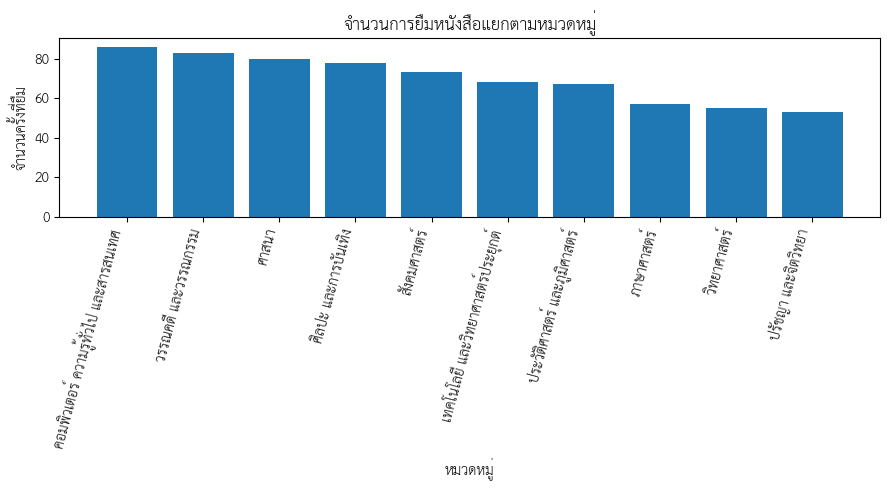

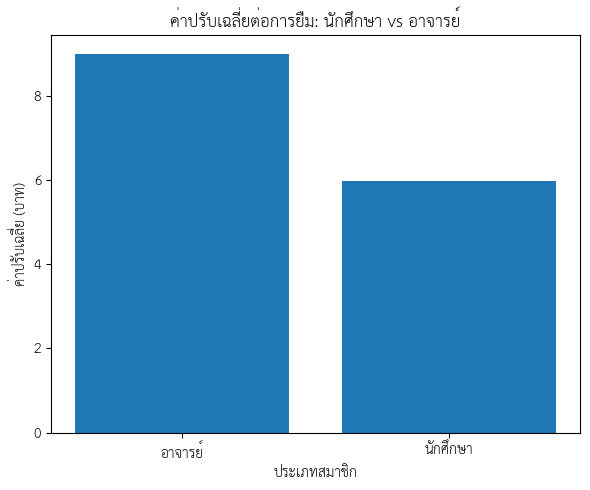

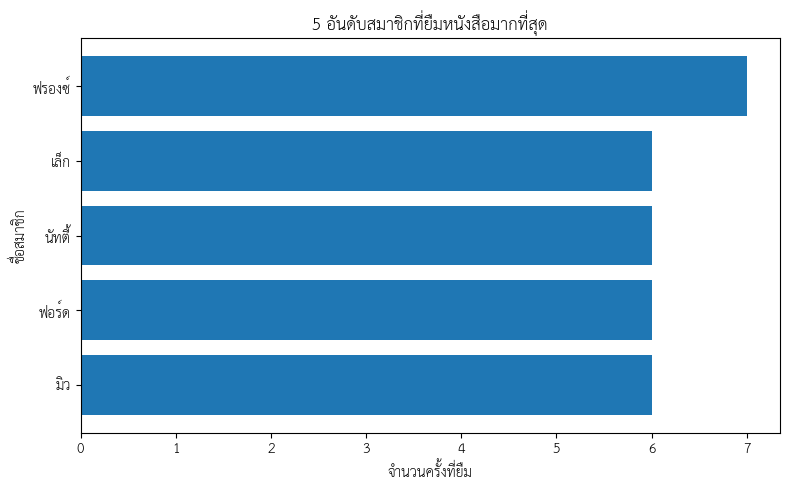

In [545]:
#สร้างกราฟ 3 รูป
import matplotlib.pyplot as plt
#กราฟที่ 1 — จำนวนการยืมตามหมวดหมู่
plt.figure(figsize=(9, 5))

plt.bar(
    category_summary["category_name"],
    category_summary["total_loans"]
)

plt.title("จำนวนการยืมหนังสือแยกตามหมวดหมู่")
plt.xlabel("หมวดหมู่")
plt.ylabel("จำนวนครั้งที่ยืม")

plt.xticks(
    rotation=75,
    ha="right"
)

plt.tight_layout()
plt.show()

#กราฟที่ 2 — ค่าปรับเฉลี่ยตามประเภทสมาชิก
plt.figure(figsize=(6, 5))

plt.bar(
    member_type_summary["member_type"],
    member_type_summary["avg_late_fee"]
)

plt.title("ค่าปรับเฉลี่ยต่อการยืม: นักศึกษา vs อาจารย์")
plt.xlabel("ประเภทสมาชิก")
plt.ylabel("ค่าปรับเฉลี่ย (บาท)")

plt.tight_layout()
plt.show()

#กราฟที่ 3 — Top 5 สมาชิกที่ยืมมากที่สุด
plt.figure(figsize=(8, 5))

plt.barh(
    top_members["name"],
    top_members["total_borrows"]
)

plt.title("5 อันดับสมาชิกที่ยืมหนังสือมากที่สุด")
plt.xlabel("จำนวนครั้งที่ยืม")
plt.ylabel("ชื่อสมาชิก")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()